# 01 · Exploratory data analysis

Kaggle Playground Series S6E3: predict whether a telecom customer churns, scored on
**ROC-AUC**. The data is synthetic — generated by a model trained on the IBM Telco
Customer Churn dataset — with 594,194 labelled training rows and 254,655 test rows,
each described by 19 raw features (demographics, subscribed services, contract and
billing).

**Findings**

* **The data is clean.** No missing values, no two training customers identical on
  all 19 features, and no test customer that duplicates a training customer — so
  there is no cleaning step, and no duplicate rows leaking across CV folds.
* **22.5% of customers churn.** The strongest single signals are contract type
  (42% churn on month-to-month vs 1% on two-year contracts), internet service
  (fibre 42%, DSL 10%), paying by electronic check (49%) and short tenure (52% in
  the first nine months vs 3% after five and a half years).
* **Most of the signal is available out of the box.** An untuned LightGBM reaches a
  cross-validated ROC-AUC of 0.9150; the best single model this project built
  reached 0.9168, and the best blend 0.9172.
* **Interactions are low-order.** Depth-1 trees (a purely additive model) already
  score at least 0.9138; depth 3 is the peak (0.9164) and deeper trees do worse.
  Small, targeted feature engineering therefore beat large sets of crosses.
* **Train and test come from the same distribution.** A classifier trained to tell
  them apart scores ROC-AUC 0.511, tuned or not, so cross-validation should track
  the private leaderboard — which it did.

**Contents**

1. Setup and data loading
2. Data quality: missing values, feature-only duplicates, train/test overlap
3. Target balance and univariate relationships with churn
4. A fast model as an EDA tool: untuned LightGBM + SHAP
5. How deep do the interactions go? (max-depth probe)
6. Train vs test: univariate drift tests and adversarial validation

*Run from the project root after `python data/fetch_data.py`. Produces figures only.*

## 1. Setup and data loading

The notebook works on the **raw** CSVs rather than on the encoded parquets that the
modelling notebooks use, so every summary below describes the data exactly as
supplied.

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import optuna
import pandas as pd
import seaborn as sns
import shap
from lightgbm import LGBMClassifier
from scipy import stats
from sklearn.metrics import roc_auc_score
from sklearn.model_selection import StratifiedKFold, cross_val_score

plt.rcParams['figure.dpi'] = 80
sns.set_theme(style='whitegrid')

# data/fetch_data.py extracts into data/; data/raw/ is also accepted.
DATA_DIR = next(p for p in (Path('data/raw'), Path('data')) if (p / 'train.csv').exists())
train_data = pd.read_csv(DATA_DIR / 'train.csv')
test_data = pd.read_csv(DATA_DIR / 'test.csv')
print(f'train {train_data.shape}   test {test_data.shape}')

train (594194, 21)   test (254655, 20)


In [2]:
# The modelling feature list: every raw column except the row id and the target.
# Mirrors FEATURES in src/data.py, the source of truth for the modelling code.
features = [c for c in train_data.columns if c not in ('id', 'Churn')]

def is_discrete(s):
    """String columns and numeric columns with fewer than 10 levels."""
    return not pd.api.types.is_numeric_dtype(s) or s.nunique() < 10

print(f'{len(features)} features')
train_data.head()

19 features


,id,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,0,Male,0,Yes,Yes,29,Yes,No,DSL,Yes,...,Yes,Yes,No,No,One year,Yes,Mailed check,60.10,1653.85,No
1,1,Male,0,Yes,Yes,58,Yes,No,DSL,Yes,...,No,Yes,Yes,No,Two year,No,Credit card (automatic),69.50,3778.20,No
2,2,Male,0,Yes,No,58,Yes,Yes,Fiber optic,No,...,No,No,Yes,Yes,Month-to-month,Yes,Electronic check,100.40,5841.35,No
3,3,Female,0,No,No,1,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,69.70,70.70,Yes
4,4,Female,0,No,No,1,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.45,70.45,Yes


## 2. Data quality

Column types and cardinalities, missing values, and summary statistics. Every
predictor except `tenure`, `MonthlyCharges` and `TotalCharges` is a 2–4-level
string (or the 0/1 `SeniorCitizen` flag), so encoding is the whole of the
preprocessing.

In [3]:
summary = pd.DataFrame({
    'dtype': train_data[features].dtypes.astype(str),
    'n_unique': train_data[features].nunique(),
    'missing_train': train_data[features].isna().sum(),
    'missing_test': test_data[features].isna().sum(),
})
summary

,dtype,n_unique,missing_train,missing_test
gender,str,2,0,0
SeniorCitizen,int64,2,0,0
Partner,str,2,0,0
Dependents,str,2,0,0
tenure,int64,72,0,0
PhoneService,str,2,0,0
MultipleLines,str,3,0,0
InternetService,str,3,0,0
OnlineSecurity,str,3,0,0
OnlineBackup,str,3,0,0


In [4]:
train_data[['tenure', 'MonthlyCharges', 'TotalCharges']].describe().T

,count,mean,std,min,25%,50%,75%,max
tenure,594194.0,36.577258,25.061922,1.00,12.00,35.00,62.0,72.00
MonthlyCharges,594194.0,65.866223,31.067444,18.25,29.90,74.10,90.8,118.75
TotalCharges,594194.0,2494.377057,2353.916710,18.80,639.65,1433.65,4263.8,8684.80


### Feature-only duplicates and train/test overlap

Duplicate checks that include the `id` column are trivially clean, so the check
below is on the **19 feature columns only**. It matters for two reasons. Identical
customers that land in different cross-validation folds let a model be scored on a
row it has effectively already seen, which inflates out-of-fold (OOF) scores. And
test rows whose exact feature vector appears in training are, in effect, partly
labelled.

The fold assignment used for every model in this project is read from
`experiments/cv_folds_seed42.csv.gz` (5-fold stratified, seed 42).

In [5]:
X_tr = train_data[features]
dup_mask = X_tr.duplicated(keep=False)

folds = (pd.read_csv('experiments/cv_folds_seed42.csv.gz')
           .set_index('id').loc[train_data['id'], 'fold'].to_numpy())
dup = train_data.loc[dup_mask, features + ['Churn']].assign(fold=folds[dup_mask.to_numpy()])
per_group = dup.groupby(features, observed=True).agg(
    size=('Churn', 'size'), n_labels=('Churn', 'nunique'), n_folds=('fold', 'nunique'))

train_keys = pd.util.hash_pandas_object(X_tr, index=False)
test_keys = pd.util.hash_pandas_object(test_data[features], index=False)
in_train = test_keys.isin(set(train_keys))

print(f'train rows in a duplicate group : {dup_mask.sum():>8,}  ({dup_mask.mean():.2%})')
print(f'duplicate groups                : {len(per_group):>8,}')
print(f'  groups with conflicting labels: {(per_group.n_labels > 1).sum():>8,}')
print(f'  groups spanning >1 CV fold    : {(per_group.n_folds > 1).sum():>8,}')
print(f'test rows whose features appear in train: {in_train.sum():,}  ({in_train.mean():.2%})')

train rows in a duplicate group :        0  (0.00%)
duplicate groups                :        0
  groups with conflicting labels:        0
  groups spanning >1 CV fold    :        0
test rows whose features appear in train: 0  (0.00%)


There are none at all: no two training customers share all 19 feature values, and
no test customer repeats a training customer's feature vector. With 1,921 distinct
`MonthlyCharges` and 31,910 distinct `TotalCharges` values, exact collisions are
unlikely by chance, and the generator evidently did not copy rows. There is nothing
to deduplicate and no duplicate-driven optimism in the out-of-fold scores.

## 3. Target balance and univariate relationships

About 22.5% of customers churn. That is imbalanced enough to make accuracy at a 0.5
threshold a weak summary of a model, which is one reason the competition is scored
on ROC-AUC, a ranking metric that does not depend on any threshold.

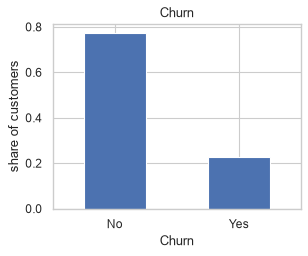

In [6]:
ax = train_data['Churn'].value_counts(normalize=True).plot.bar(figsize=(4, 3), rot=0)
ax.set_ylabel('share of customers')
ax.set_title('Churn')
plt.show()

### Each feature against the target

Counts split by `Churn` first. Because the classes are imbalanced these panels
mostly show where the customers are; the normalised version after it is the one
that shows the signal.

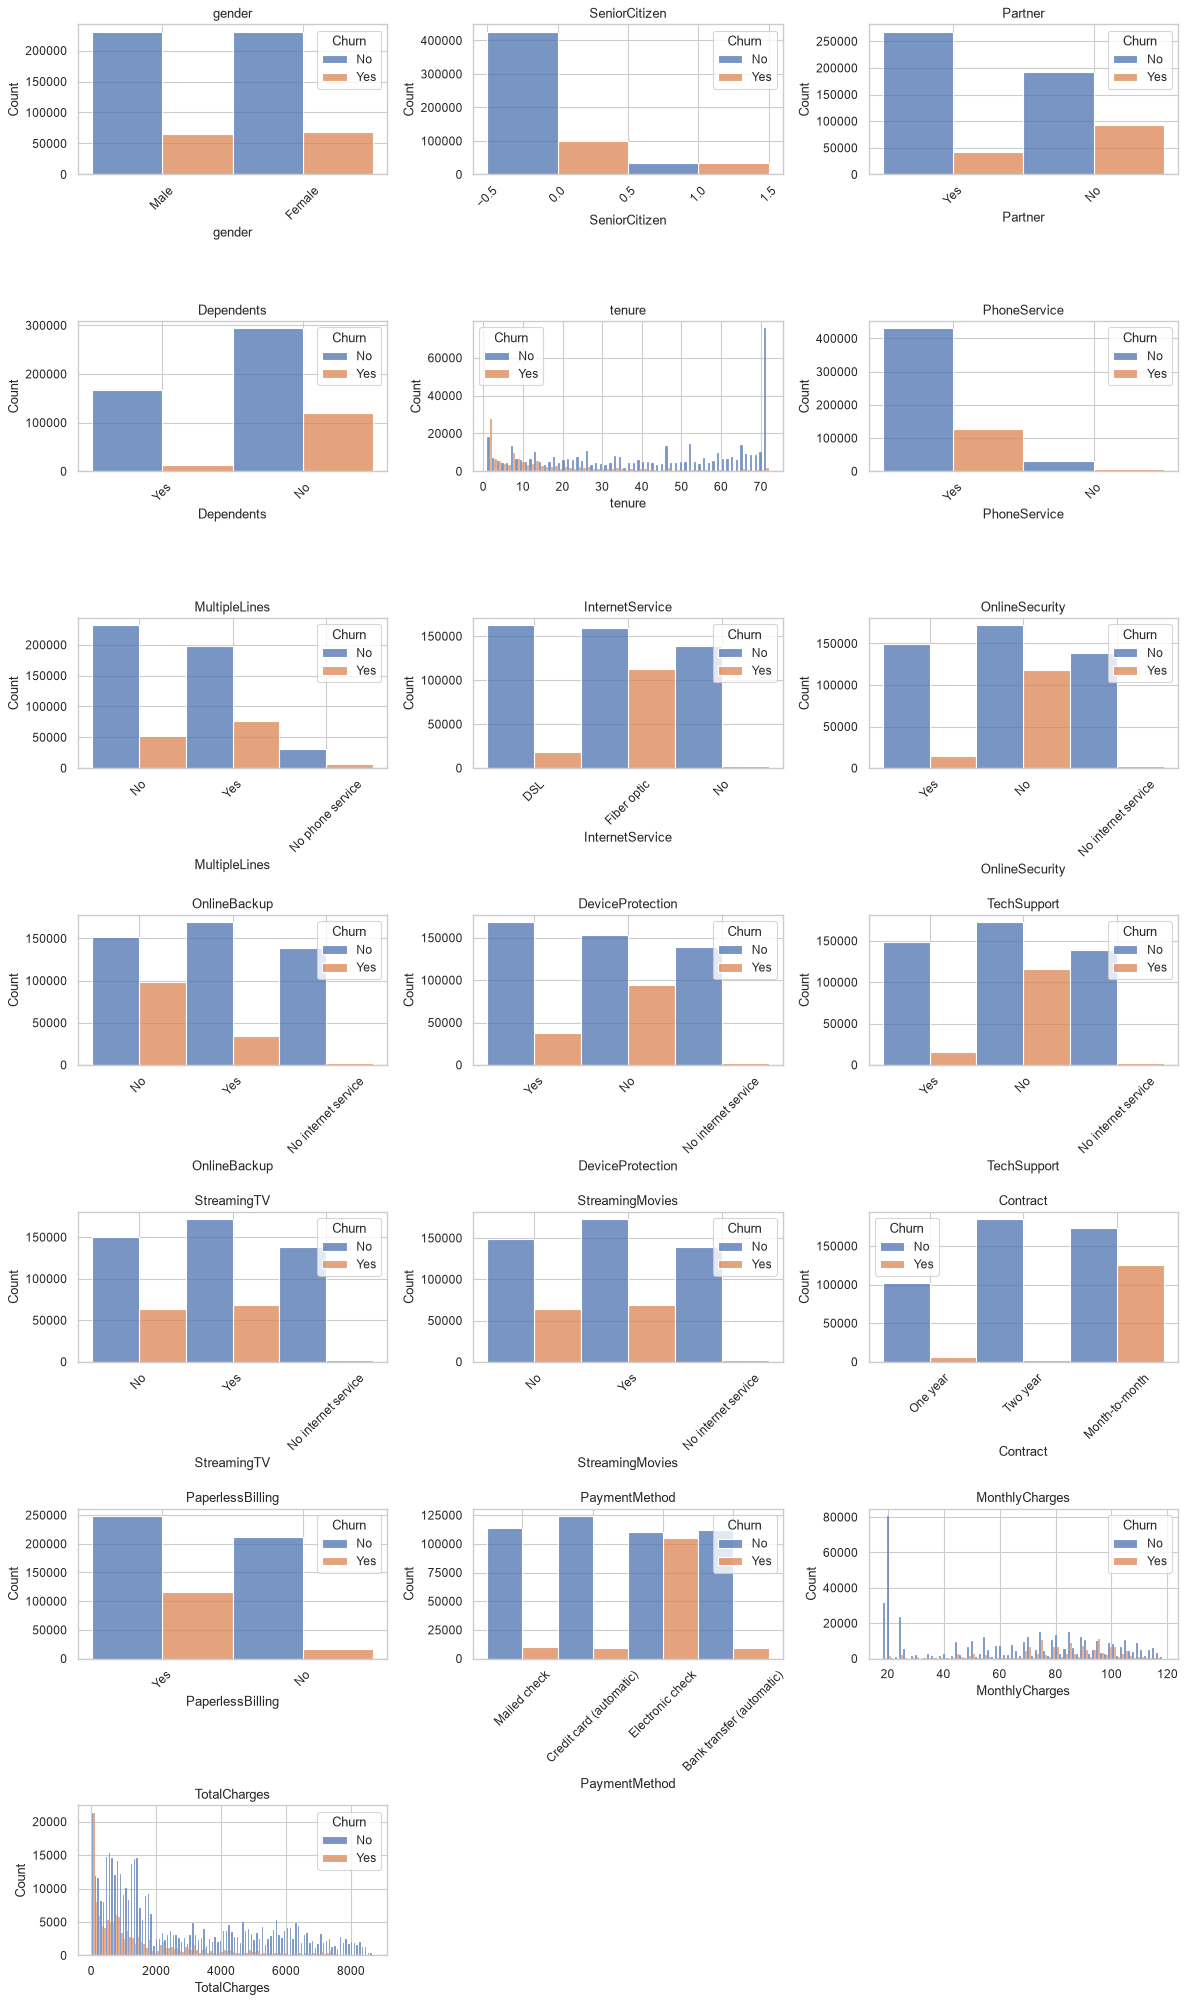

In [7]:
def feature_grid(data, cols, hue=None, multiple='dodge'):
    """One histogram per feature; discrete (string or <10 levels) columns as bars."""
    n_cols = 3
    n_rows = (len(cols) + n_cols - 1) // n_cols
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(5 * n_cols, 3.6 * n_rows))
    axes = axes.flatten()
    for ax, feature in zip(axes, cols):
        discrete = is_discrete(data[feature])
        sns.histplot(data=data, x=feature, hue=hue, multiple=multiple,
                     discrete=discrete, ax=ax)
        ax.set_title(feature)
        if discrete:
            ax.tick_params(axis='x', rotation=45)
    for ax in axes[len(cols):]:
        fig.delaxes(ax)
    plt.tight_layout()
    plt.show()

feature_grid(train_data, features, hue='Churn')

### The same panels normalised: churn rate per level

Each bar is stacked to 1, so the `Churn = Yes` share reads directly as the churn
rate for that level or bin. Month-to-month contracts churn at ~42% against ~1% for
two-year contracts; fibre-optic internet at ~42% against ~10% for DSL;
electronic-check payers at ~49%; and the shortest-tenure bin at over 50% against a
few percent for the longest. `gender` sits flat at the base rate.

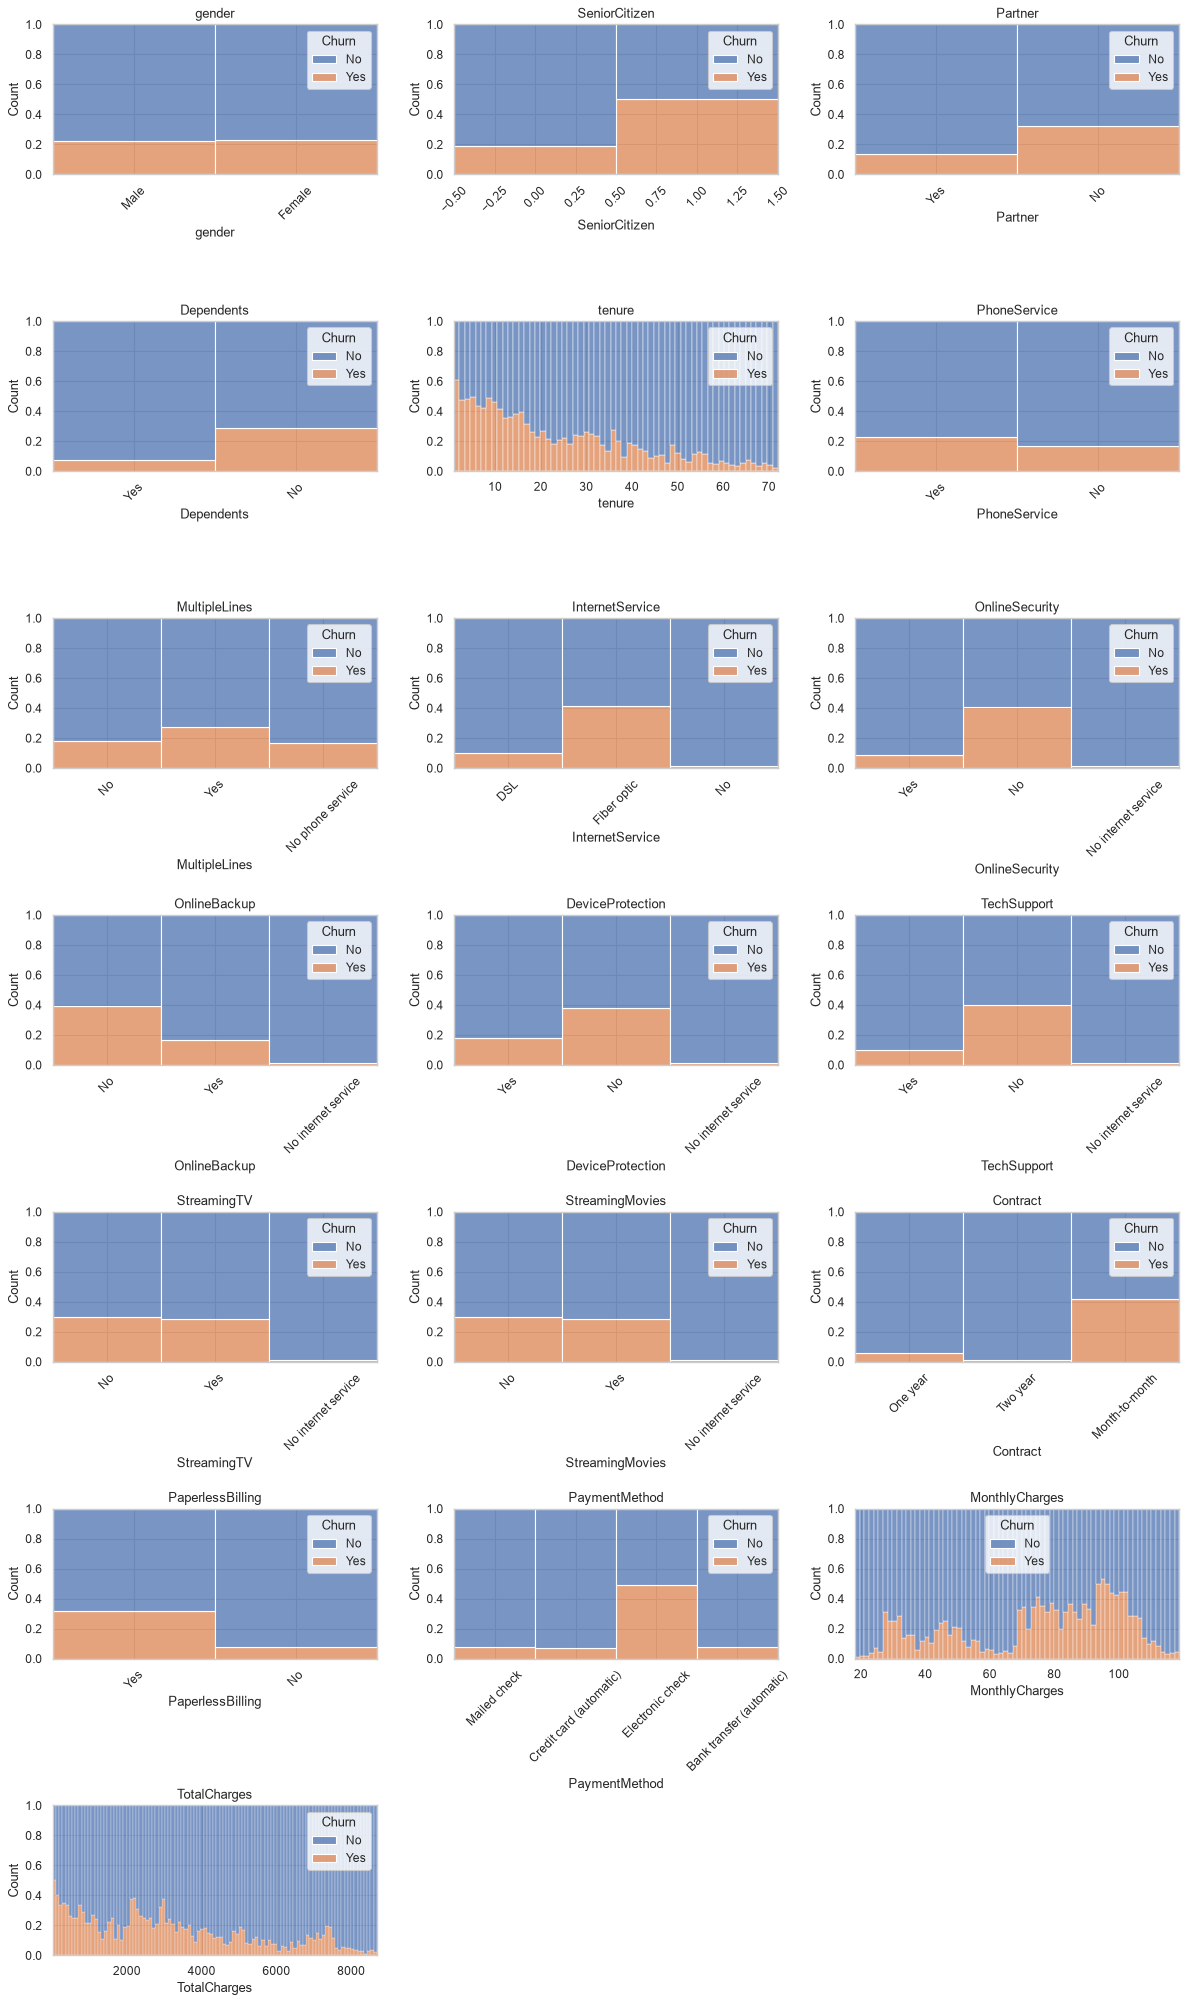

In [8]:
feature_grid(train_data, features, hue='Churn', multiple='fill')

## 4. A fast model as an EDA tool: untuned LightGBM + SHAP

An untuned gradient-boosted model, read through its SHAP values, answers three
questions at once: roughly what score is achievable, which features matter, and in
which direction each one pushes the prediction. String columns are passed as pandas
`category` dtype, which LightGBM handles natively without one-hot encoding.

SHAP values are per-prediction Shapley values: each feature's signed contribution
to one customer's predicted churn log-odds, computed exactly for tree ensembles by
`TreeExplainer`. In the beeswarm plot each dot is one customer; the x-position is
the SHAP value and the colour is the feature's value (red high, blue low). The bar
plot is the mean |SHAP| per feature, a global importance ranking. More background:
[docs/reference/eda_glossary.md](docs/reference/eda_glossary.md).

In [9]:
X_lgbm = train_data[features].copy()
cat_features = [c for c in features if not pd.api.types.is_numeric_dtype(X_lgbm[c])]
X_lgbm[cat_features] = X_lgbm[cat_features].astype('category')
y = (train_data['Churn'] == 'Yes').astype(int)

cv3 = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)
auc = cross_val_score(LGBMClassifier(verbose=-1, random_state=42), X_lgbm, y,
                      cv=cv3, scoring='roc_auc')
print(f'Untuned LightGBM, 3-fold CV ROC-AUC: {auc.mean():.4f} ± {auc.std():.4f}')

lgbm = LGBMClassifier(verbose=-1, random_state=42).fit(X_lgbm, y)
X_sample = X_lgbm.sample(n=5000, random_state=42)
shap_values = shap.TreeExplainer(lgbm)(X_sample)

Untuned LightGBM, 3-fold CV ROC-AUC: 0.9150 ± 0.0006


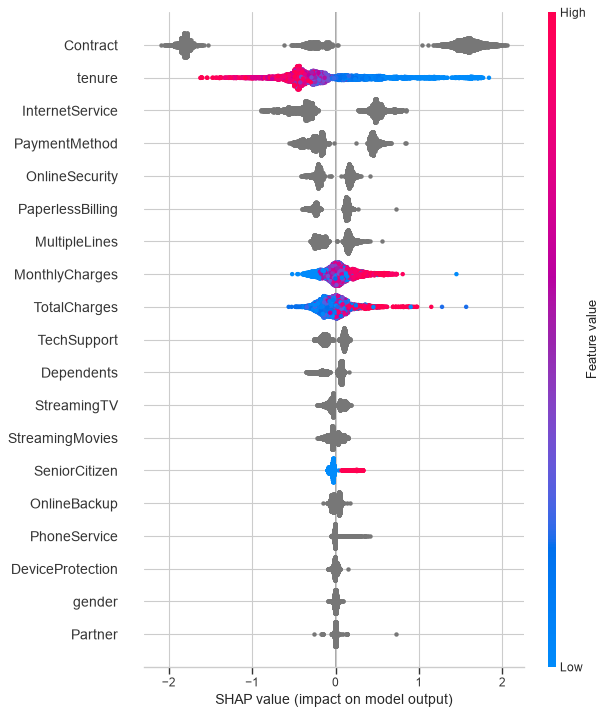

In [10]:
shap.summary_plot(shap_values, X_sample)

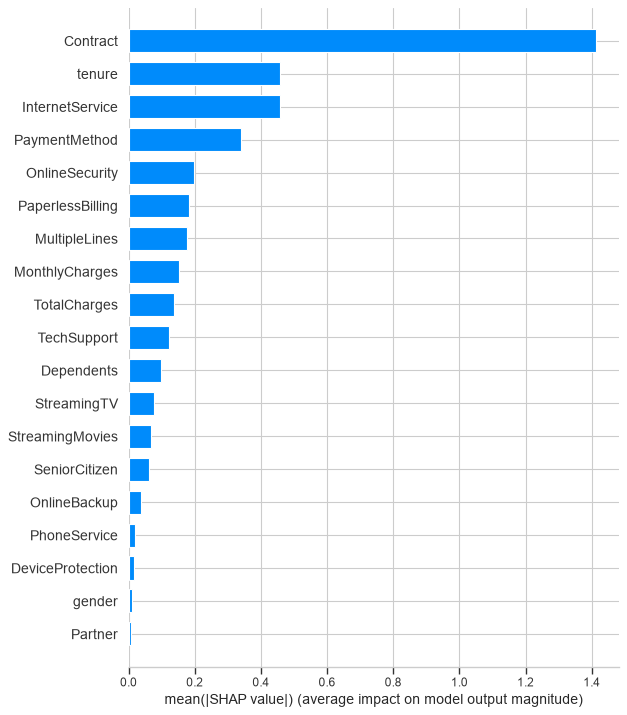

In [11]:
shap.summary_plot(shap_values, X_sample, plot_type='bar')

`Contract` dominates — its mean |SHAP| of about 1.4 log-odds is three times the next
feature's — followed by `tenure`, `InternetService` and `PaymentMethod`, the same four
that stood out in the churn-rate panels. `gender`, `Partner`, `DeviceProtection` and
`PhoneService` contribute almost nothing. The untuned model's 0.9150 is within 0.002
of the best single model the project produced (0.9168, `02_Experiments.ipynb`):
everything after this point is fought over in the third and fourth decimal places.

## 5. How deep do the interactions go? A max-depth probe

If the target depended on high-order interactions between features, deeper trees
would keep improving the cross-validated score. If it is close to additive in the
features, the score plateaus at shallow depth. Here LightGBM is fitted with
`max_depth` fixed at 1 (no interactions at all: a sum of one-feature effects)
through 8, with `num_leaves = 2**depth` and early stopping inside
`lightgbm.cv` on the same 3-fold split for every depth.

 max_depth  cv_auc  rounds gain_vs_depth_1
         1 0.91384    3000        +0.00000
         2 0.91628    3000        +0.00245
         3 0.91636    1297        +0.00252
         4 0.91619     735        +0.00235
         5 0.91603     415        +0.00219
         6 0.91586     248        +0.00203
         7 0.91565     193        +0.00181
         8 0.91544     148        +0.00161


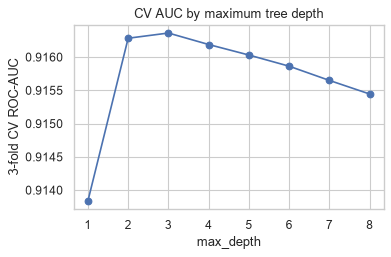

In [12]:
import lightgbm as lgb

dset = lgb.Dataset(X_lgbm, label=y, categorical_feature=cat_features, free_raw_data=False)
probe = []
for depth in range(1, 9):
    params = dict(objective='binary', metric='auc', learning_rate=0.1,
                  max_depth=depth, num_leaves=2 ** depth, min_child_samples=100,
                  verbose=-1, seed=42)
    res = lgb.cv(params, dset, num_boost_round=3000, folds=cv3.split(X_lgbm, y),
                 callbacks=[lgb.early_stopping(100, verbose=False)])
    probe.append({'max_depth': depth, 'cv_auc': res['valid auc-mean'][-1],
                  'rounds': len(res['valid auc-mean'])})
probe = pd.DataFrame(probe)
probe['gain_vs_depth_1'] = probe['cv_auc'] - probe['cv_auc'].iloc[0]
print(probe.to_string(index=False, formatters={'cv_auc': '{:.5f}'.format,
                                               'gain_vs_depth_1': '{:+.5f}'.format}))

ax = probe.plot(x='max_depth', y='cv_auc', marker='o', legend=False, figsize=(5, 3))
ax.set_ylabel('3-fold CV ROC-AUC')
ax.set_title('CV AUC by maximum tree depth')
plt.show()

A depth-1 model — a sum of one-feature effects, with no interactions — reaches at
least 0.9138 (depths 1 and 2 hit the 3,000-round cap, so both are slight
underestimates). Allowing pairwise interactions adds about 0.0025; depth 3 is the
peak at 0.9164, and deeper trees score slightly *lower*. The signal is main effects
plus a few low-order interactions. That is why the feature engineering that worked
was small — one ratio and two pairwise crosses with `Contract` — and why larger sets
of engineered crosses scored worse
([docs/feature_engineering.md](docs/feature_engineering.md)).

## 6. Train vs test

If the test set were drawn from a different distribution than the training set,
cross-validation scores would stop predicting leaderboard scores. Two checks
follow: per-feature distribution tests, then adversarial validation, which tests
the joint distribution.

In [13]:
rows = []
for feature in features:
    if is_discrete(train_data[feature]):
        table = pd.concat([train_data[feature].value_counts().rename('train'),
                           test_data[feature].value_counts().rename('test')], axis=1).fillna(0)
        stat, p, _, _ = stats.chi2_contingency(table)
        test_name = 'chi-square'
    else:
        stat, p = stats.ks_2samp(train_data[feature], test_data[feature])
        test_name = 'Kolmogorov-Smirnov'
    rows.append({'feature': feature, 'test': test_name, 'statistic': stat, 'p_value': p})

drift = pd.DataFrame(rows)
drift['p < 0.05'] = drift['p_value'] < 0.05
drift.style.format({'statistic': '{:.4f}', 'p_value': '{:.3e}'})

,feature,test,statistic,p_value,p < 0.05
0,gender,chi-square,0.0994,7.526e-01,False
1,SeniorCitizen,chi-square,0.4055,5.243e-01,False
2,Partner,chi-square,45.6812,1.392e-11,True
3,Dependents,chi-square,4.1864,4.075e-02,True
4,tenure,Kolmogorov-Smirnov,0.0171,1.550e-45,True
5,PhoneService,chi-square,0.2691,6.039e-01,False
6,MultipleLines,chi-square,18.1883,1.123e-04,True
7,InternetService,chi-square,0.0005,9.997e-01,False
8,OnlineSecurity,chi-square,29.0948,4.810e-07,True
9,OnlineBackup,chi-square,45.9021,1.078e-10,True


Fourteen of the 19 features are flagged at p < 0.05, but the statistics themselves
are tiny: the largest Kolmogorov–Smirnov distance is 0.018. With about 594,000 and
255,000 rows these tests detect differences far too small to matter to a model. They
also look at one feature at a time; adversarial validation tests the joint
distribution, with a model's power.

### Adversarial validation

A classifier is trained to tell training rows from test rows. If it cannot do
better than chance — an out-of-fold **ROC-AUC of about 0.5** — the two sets are
indistinguishable in their joint distribution, not just feature by feature.

In [14]:
combined = pd.concat([train_data[features].assign(is_train=1),
                      test_data[features].assign(is_train=0)], ignore_index=True)
combined[cat_features] = combined[cat_features].astype('category')
X_adv, y_adv = combined[features], combined['is_train']

def adversarial_oof_auc(params, X, y, n_splits=5):
    cv = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=42)
    oof = np.zeros(len(y))
    for tr, va in cv.split(X, y):
        model = LGBMClassifier(**params).fit(X.iloc[tr], y.iloc[tr])
        oof[va] = model.predict_proba(X.iloc[va])[:, 1]
    return roc_auc_score(y, oof)

default_auc = adversarial_oof_auc({'verbose': -1, 'random_state': 42}, X_adv, y_adv)
print(f'Adversarial OOF ROC-AUC, default LightGBM: {default_auc:.4f}')

Adversarial OOF ROC-AUC, default LightGBM: 0.5105


A null result is only convincing if the classifier had a fair chance, so the same
task is re-run under a 20-trial Optuna search over LightGBM's capacity and
regularisation parameters. To keep the search affordable it tunes on a 250,000-row
stratified sample with 3-fold CV; the best configuration is then re-scored with
5-fold CV on all 848,849 rows.

In [15]:
optuna.logging.set_verbosity(optuna.logging.WARNING)
X_s = X_adv.sample(n=250_000, random_state=42)
y_s = y_adv.loc[X_s.index]

def objective(trial):
    params = {
        'n_estimators':      trial.suggest_int('n_estimators', 100, 800),
        'learning_rate':     trial.suggest_float('learning_rate', 0.01, 0.3, log=True),
        'num_leaves':        trial.suggest_int('num_leaves', 15, 255),
        'min_child_samples': trial.suggest_int('min_child_samples', 10, 200),
        'subsample':         trial.suggest_float('subsample', 0.5, 1.0),
        'subsample_freq':    1,
        'colsample_bytree':  trial.suggest_float('colsample_bytree', 0.5, 1.0),
        'reg_lambda':        trial.suggest_float('reg_lambda', 1e-8, 10.0, log=True),
        'verbose': -1, 'random_state': 42,
    }
    return adversarial_oof_auc(params, X_s, y_s, n_splits=3)

study = optuna.create_study(direction='maximize', sampler=optuna.samplers.TPESampler(seed=42))
study.optimize(objective, n_trials=20)
best = {**study.best_params, 'subsample_freq': 1, 'verbose': -1, 'random_state': 42}
tuned_auc = adversarial_oof_auc(best, X_adv, y_adv)
print(f'Best inner-CV AUC on the sample : {study.best_value:.4f}')
print(f'Tuned model, 5-fold OOF AUC     : {tuned_auc:.4f}')

Best inner-CV AUC on the sample : 0.5124
Tuned model, 5-fold OOF AUC     : 0.5113


The out-of-fold AUC is 0.511 with default settings and 0.511 after tuning: a hair
above chance, and extra capacity does not make the two sets separable. For modelling
purposes train and test come from the same distribution. Two consequences followed.
Cross-validation tracked the private leaderboard closely (Spearman 0.977 across 68
submissions, `04_Results.ipynb`). And techniques that exploit train/test shift, such
as pseudo-labelling, had nothing to offer here
([docs/stacking_experiments.md](docs/stacking_experiments.md)).